investigate robustness of perturbation analysis and saliency analysis for all available modles 2-4 (maybe 1?)
compute rank correlations for the same subject for all paris of repetitions

In [1]:
import pathlib
import random
import copy
import numpy as np
import torch

from captum.attr import *
import matplotlib.pyplot as plt
from omegaconf import OmegaConf
import yaml
import argparse
from data.data_loader import load_eeg_data, get_sliding_window_data, create_dataloader
import os
import mne
from tqdm import tqdm
from sklearn.preprocessing import MinMaxScaler
import pandas as pd

from sliced_wasserstein import sliced_wasserstein_distance
from c2st import c2st_knn, c2st_nn, c2st_rf

from models.s4net import S4PatchedFinalNet,TrunkNet, HeadNet
import seaborn as sns

CUDA extension for structured kernels (Cauchy and Vandermonde multiplication) not found. Install by going to extensions/kernels/ and running `python setup.py install`, for improved speed and memory efficiency. Note that the kernel changed for state-spaces 4.0 and must be recompiled.


In [2]:
CFG_YAML = """
wandb:
 key: f0c92a0059bf12e2647f0a1c22fdcd12555fa6df
model:
dataset:
 data_directory: /home/marco/Documents/GitHub/tms_eeg_decoding/data
 #file_name: subject_{:03d}_preprocessed_combined_py.fif
 file_name: subject_{:03d}_preprocessed_combined_py.fif
 exclude_timepoints: 100
 subject_index: 1
 test_subject_indices: [1,2,13,24,26,27,29,34,35,41, 42,43,45,46,47,48,52,55,56,57,60,62,67,69,72,73,79,80,86,88,92,102]
 #test_subject_indices: [2]
training:
 training_start_len: 100
 pretrain_epochs: 100
 pretrain_lr: 0.0001
 val_window_len: 1
 epochs_per_window: 10
 num_warmup_epochs: 5
 num_epochs: 800
 slide_step: 1
 num_warmup_epochs_per_window: 0
 lr: 0.005 #maybe change back to 0.0001
 nll_beta: 0.001
 num_warmup_epochs: 0
 batch_size: 50 #better to use 50
 random_seed: 42
 precision: bf16
 kde_lambda: 0.5
 finetune_entire_model: true # Set to true to finetune the entire model, false for transformer only
exp_name: S4_S4EEGNet_ema
"""

def load_config():
    cfg = OmegaConf.create(yaml.safe_load(CFG_YAML))
    cfg.exp_name = f"{cfg.exp_name}_subject_{cfg.dataset.subject_index}"
    return cfg

def parse_args():
    parser = argparse.ArgumentParser()
    parser.add_argument("--update_conf", nargs="*", help="Updates to the configuration in the form of key=value pairs", default=[])
    parser.add_argument("-f", "--fff", help="A dummy argument to handle IPython's default argument", default="1")
    return parser.parse_args()

def update_config(cfg, cli_args):
    for update in cli_args.update_conf:
        key, value = update.split("=")
        try:
            value = eval(value)
        except:
            pass
        OmegaConf.update(cfg, key, value, force_add=True)
    cfg.exp_name = cfg.exp_name + "_" + "_".join(cli_args.update_conf)
    print(OmegaConf.to_yaml(cfg))
    return cfg


def save_config(cfg):
    os.makedirs("conf/sweeps", exist_ok=True)
    os.makedirs("exp/withinsubs", exist_ok=True)
    with open(f"conf/sweeps/withinsubs_{cfg.exp_name}.yaml", "w") as f:
        f.write(OmegaConf.to_yaml(cfg))

In [3]:
freq_bands = {
              "delta": (0, 4),
              "theta": (4, 8),             
              "alpha": (8, 12),
              "beta": (12, 30),
              "gamma": (30, 45)}

amplification_factors = [0.5,0.8,0.9,1.1,1.2,1.5]

# robustness of perturbation

## correlation

### abs values

In [4]:
 #   mean_diff_per_channel, median_diff_per_channel = calculate_diff_per_channel(original_predictions, freq_bands, amplification_factors, ch_names, #subject_index=subject_index)
def median_difference_all_subjects(data_all_subjects, amplification_factors, take_abs=True, rep=2):
    median_diff_per_channel_all_subjects = {}
    load_dir_og = f"/home/marco/Documents/GitHub/tms_eeg_decoding/subject_interpretability/gradshap_explanations_rep_{rep}"
    load_dir_perturbed = "/home/marco/Documents/GitHub/tms_eeg_decoding/perturb_samples/parallel_perturbation_power"
    for subject_index, _ in data_all_subjects.items():
        cfg = load_config()
        cfg.dataset.subject_index = subject_index
        _, _, _, _, _, _, _, ch_names = load_eeg_data(cfg)
        file_name_og = f"gradshap_data_subject_{subject_index}_rep_{rep}.npy"
        file_path_og = os.path.join(load_dir_og, file_name_og)
        data = np.load(file_path_og, allow_pickle=True).item()
        predictions = data["predictions"]
        #ch_names = data["ch_names"]

        median_diff_per_channel = {}
        for band_name, (low_freq, high_freq) in freq_bands.items():
            median_diff_per_channel[band_name] = {}
            for factor in amplification_factors:
                file_name_pert= f"parallel_perturbed_prediction_dict_{band_name}_channel_amp_factor_{factor}_subject_{subject_index}_rep_{rep}.npy"
                file_path_pert = os.path.join(load_dir_perturbed, file_name_pert)
                perturbed_data = np.load(file_path_pert , allow_pickle=True).item()
                median_diff_per_channel[band_name][factor] = {}
                for ch_name in ch_names:
                    perturbed_amplitude = perturbed_data[ch_name]
                    if take_abs:
                        diff = np.abs(predictions - perturbed_amplitude)
                    else:
                        diff = predictions - perturbed_amplitude
                    median_diff_per_channel[band_name][factor][ch_name] = np.median(diff)
        median_diff_per_channel_all_subjects[subject_index] = median_diff_per_channel
    return median_diff_per_channel_all_subjects


In [5]:
def load_all_subjects_topk(rep=2, take_abs=True):
    load_dir = f"/home/marco/Documents/GitHub/tms_eeg_decoding/subject_interpretability/"
    if take_abs:
        file_name = f"all_subject_channel_importances_gradshap_abs_rep_{rep}.npy"
    else:
        file_name = f"all_subject_channel_importances_gradshap_rep_{rep}.npy"
    load_file = os.path.join(load_dir, file_name)
    topk = np.load(load_file, allow_pickle=True).item()
    return topk

In [29]:
median_diff_all_reps = []
for rep in [1,2,3,4,5]:
    topk_pert = load_all_subjects_topk(rep=rep, take_abs=True)
    median_diff_per_channel_all_subjects = median_difference_all_subjects(topk_pert, amplification_factors, take_abs=True, rep=rep)
    median_diff_all_reps.append(median_diff_per_channel_all_subjects)

Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)

In [7]:
import numpy as np
import pandas as pd
from scipy import stats
import itertools
# Create a function to compute correlations and rank correlations
def compute_correlations(median_diff_all_reps):
    # Initialize dictionaries to store correlations

    
    # Get all subjects that exist in both repetitions
    list_pairs = itertools.combinations(np.arange(0,len(median_diff_all_reps)), 2)
    subjects = median_diff_all_reps[0].keys()
    pearson_corrs = {}
    spearman_corrs = {}
    for l1,l2 in list_pairs:
        pearson_corrs[(l1,l2)] = {}
        spearman_corrs[(l1,l2)] = {}
   
        median_diff1 = median_diff_all_reps[l1]
        median_diff2 = median_diff_all_reps[l2]
        for subject in subjects:
            pearson_corrs[(l1,l2)][subject] = {}
            spearman_corrs[(l1,l2)][subject] = {}
        
            for band in freq_bands.keys():
                for factor in amplification_factors:
                    channels = median_diff1[subject][band][factor].keys()
                    # Extract values for correlation calculation
                    values_rep3 = [median_diff1[subject][band][factor][ch] for ch in channels]
                    values_rep4 = [median_diff2[subject][band][factor][ch] for ch in channels]
                
                    # Calculate correlations
                    pearson_corr, _ = stats.pearsonr(values_rep3, values_rep4)
                    spearman_corr, _ = stats.spearmanr(values_rep3, values_rep4)
                
                    # Store results
                    if band not in pearson_corrs[(l1,l2)][subject]:
                        pearson_corrs[(l1,l2)][subject][band] = {}
                        spearman_corrs[(l1,l2)][subject][band] = {}
                    
                    pearson_corrs[(l1,l2)][subject][band][factor] = pearson_corr
                    spearman_corrs[(l1,l2)][subject][band][factor] = spearman_corr
    
    return pearson_corrs, spearman_corrs

# for each pair of repetitions, compute correlations for each subject in each frequency band and amplification factor


# Create summary dataframes


In [8]:
def average_rank_correlations_subject(correlations, freq_bands, amplification_factors):
    # for each subject, frequency band and amplification factor, average the rank correlations across pairs of repetitions
    all_rank_correlations = {}
    for subject in correlations[(0,1)].keys():
        all_rank_correlations[subject] = {}
        for band in freq_bands.keys():
            all_rank_correlations[subject][band] = {}
            for factor in amplification_factors:
                all_rank_correlations[subject][band][factor] = []
                for pair in correlations.keys():
                    all_rank_correlations[subject][band][factor].append(correlations[pair][subject][band][factor])
    
    for subject in correlations[(0,1)].keys():
        for band in freq_bands.keys():
            for factor in amplification_factors:
                all_rank_correlations[subject][band][factor] = np.mean(all_rank_correlations[subject][band][factor])
    
    return all_rank_correlations
    
  

In [9]:
import numpy as np

def plot_average_correlations_subject(average_correlations, freq_bands, amplification_factor=1.5):
    # Set up the figure with subplots for each frequency band
    fig, axes = plt.subplots(1, len(freq_bands), figsize=(20, 5), sharey=True)
    
    # Get all subjects
    subjects = list(average_correlations.keys())
    all_corr_values = {}
    # Loop through each frequency band
    for i, (band, (low_freq, high_freq)) in enumerate(freq_bands.items()):
        # Extract correlation values for this band and amplification factor
        corr_values = [average_correlations[subject][band][amplification_factor] for subject in subjects]
        all_corr_values[band] = corr_values
        
        # Plot the values
        axes[i].bar(range(len(subjects)), corr_values, color='skyblue')
        axes[i].set_title(f"{band} ({low_freq}-{high_freq} Hz)")
        axes[i].set_xlabel("Subject Index")
        if i == 0:
            axes[i].set_ylabel("Spearman Rank Correlation")
        
        # Set x-ticks to be subject indices
        axes[i].set_xticks(range(len(subjects)))
        axes[i].set_xticklabels(subjects, rotation=90, fontsize=8)
        
        # Add a horizontal line at the mean correlation
        mean_corr = np.nanmean(corr_values)
        axes[i].axhline(y=mean_corr, color='red', linestyle='--', label=f'Mean: {mean_corr:.2f}')
        axes[i].legend()
    
    plt.tight_layout()
    plt.suptitle(f'Average Spearman Rank Correlations for Amplification Factor {amplification_factor}', y=1.05)
    plt.show()

    return all_corr_values





In [30]:
pearson_correlations, spearman_correlations = compute_correlations(median_diff_all_reps)
average_rank_correlations = average_rank_correlations_subject(spearman_correlations, freq_bands, amplification_factors)

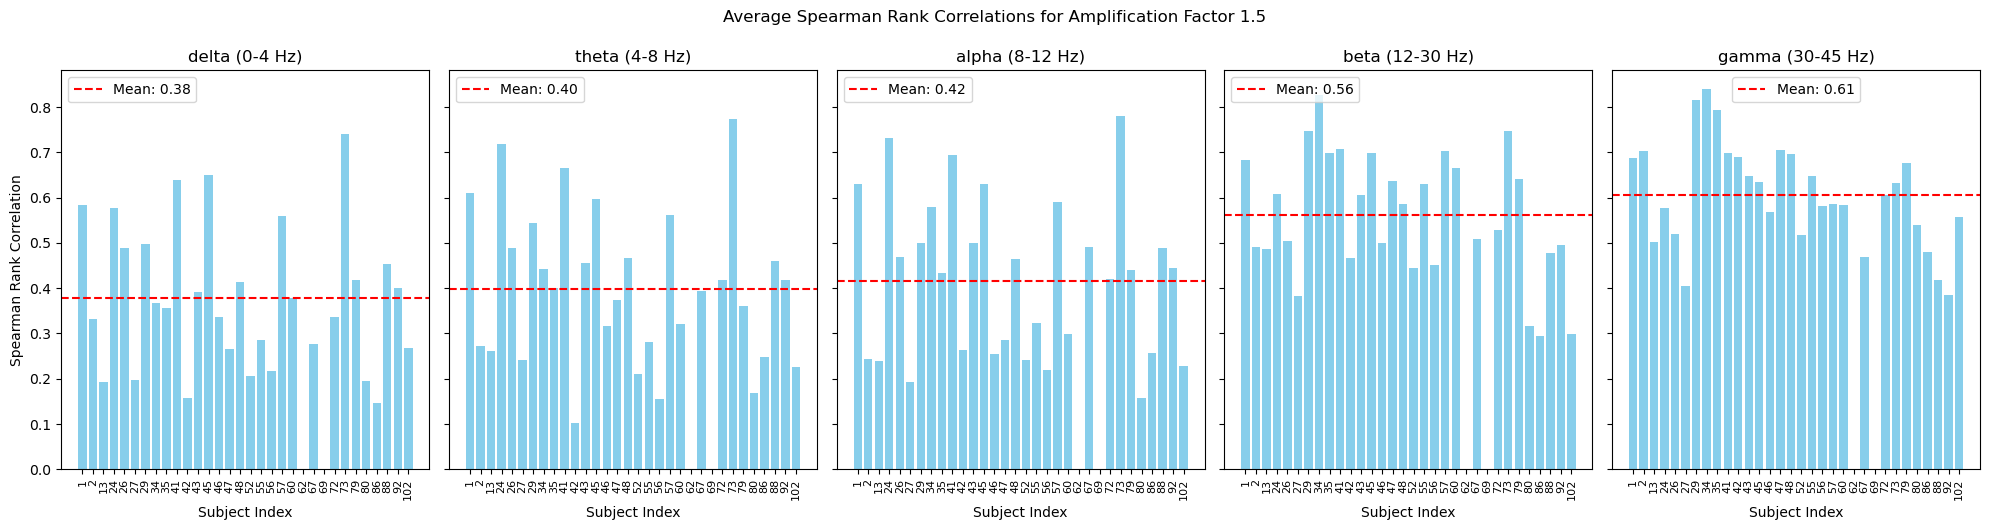

In [31]:
all_corr_values = plot_average_correlations_subject(average_rank_correlations, freq_bands, amplification_factor=1.5)

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def plot_average_correlations(all_corr_values, freq_bands, amplification_factor=1.5, nan_treatment='omit', use_abs=True):
    """
    Plot distribution of Spearman rank correlations for each frequency band.
    
    Parameters:
    -----------
    all_corr_values : dict
        Dictionary containing correlation values for each frequency band
    freq_bands : dict
        Dictionary of frequency bands with format {band_name: (low_freq, high_freq)}
    amplification_factor : float, optional
        The amplification factor used in the analysis
    nan_treatment : str, optional
        How to handle NaN values: 'omit' to remove them, 'zero' to replace with zeros
    """
    # Define colors for each frequency band with better color scheme
    colors = {
        'delta': '#E63946',  # Crimson red
        'theta': '#F9A826',  # Orange
        'alpha': '#2A9D8F',  # Teal
        'beta':  '#457B9D',  # Blue
        'gamma': '#6A0DAD',  # Purple
    }
    
    # Create a subplot for each frequency band in a single row
    fig, axes = plt.subplots(1, len(freq_bands), figsize=(15, 4), sharey=True, sharex=True)
    if use_abs:
        fig.suptitle(f'Robustness of Channel Importances for amplification factor {amplification_factor}', 
                 fontsize=20, y=1.05)
    else:
        fig.suptitle(f'Robustness of Channel Influences for amplification factor {amplification_factor}', 
                 fontsize=20, y=1.05)

    
    # Process and plot data for each frequency band
    for i, (band_name, (low_freq, high_freq)) in enumerate(freq_bands.items()):
        corr_values = all_corr_values[band_name]
        
        # Handle NaN values according to specified treatment
        if nan_treatment == 'omit':
            corr_values = [val for val in corr_values if not np.isnan(val)]
        elif nan_treatment == 'zero':
            corr_values = [val if not np.isnan(val) else 0 for val in corr_values]
        
        # Calculate statistics
        mean_corr = np.mean(corr_values)
        median_corr = np.median(corr_values)
        
        # Plot histogram with kernel density estimate
        sns.histplot(
            corr_values, 
            kde=True, 
            ax=axes[i], 
            color=colors[band_name],
            alpha=0.7,
            edgecolor='white',
            linewidth=0.8,
            bins="auto"
        )
        
        # Add vertical line for mean
        axes[i].axvline(x=mean_corr, color='black', linestyle='-', linewidth=1.5, 
                       label=f'Mean: {mean_corr:.3f}')
        
        # Title and labels with nicer formatting
        axes[i].set_title(f'{band_name.capitalize()}', 
                         fontsize=17, fontweight='bold')
        
        if i == 0:  # Only set y-label for the first subplot
            axes[i].set_ylabel('Count', fontsize=16)
        axes[i].set_xlabel('Rank Correlation', fontsize=15)
        
        # Format the ticks
        axes[i].tick_params(axis='both', labelsize=15)
        
        # Add legend
        axes[i].legend(fontsize=14)
        
        # Remove top and right spines for cleaner look
        sns.despine(ax=axes[i])

    plt.tight_layout()
    plt.subplots_adjust(top=0.85, wspace=0.2)
    
    return fig, axes


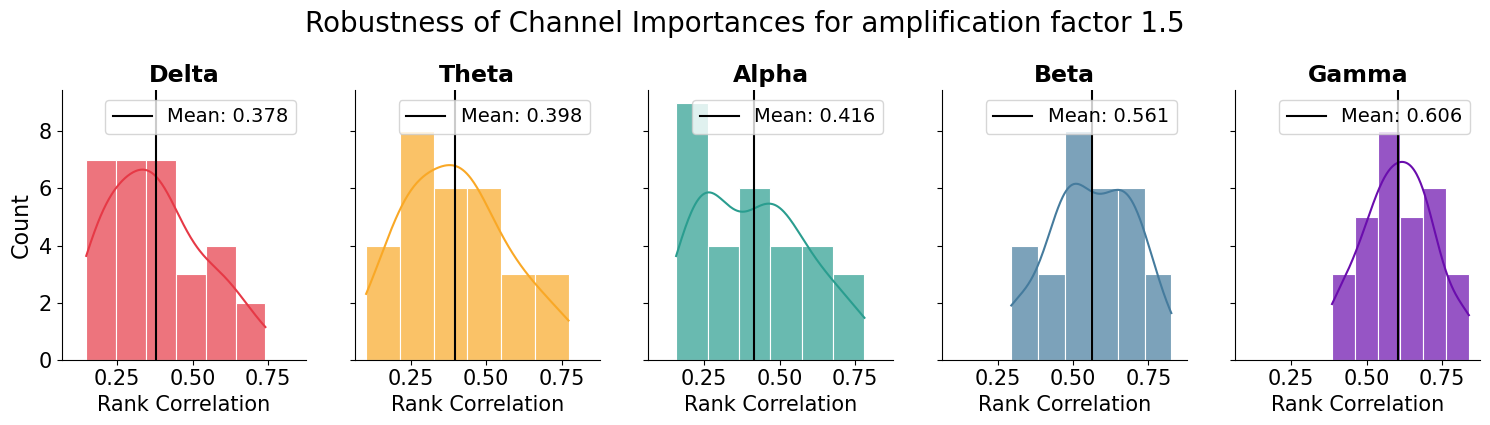

In [34]:
fig,_ = plot_average_correlations(all_corr_values, freq_bands, amplification_factor=1.5)
fig.savefig("power_robustness_spearman_rank_correlations_abs.png", bbox_inches='tight', dpi=300)

In [24]:
#plot_average_correlations(all_corr_values, freq_bands, amplification_factor=1.5, nan_treatment='zero')

### non abs values

In [35]:
median_diff_all_reps = []
for rep in [1,2,3,4,5]:
    topk_pert = load_all_subjects_topk(rep=rep, take_abs=False)
    median_diff_per_channel_all_subjects = median_difference_all_subjects(topk_pert, amplification_factors, take_abs=False, rep=rep)
    median_diff_all_reps.append(median_diff_per_channel_all_subjects)

Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)

In [36]:
pearson_correlations_abs, spearman_correlations = compute_correlations(median_diff_all_reps)


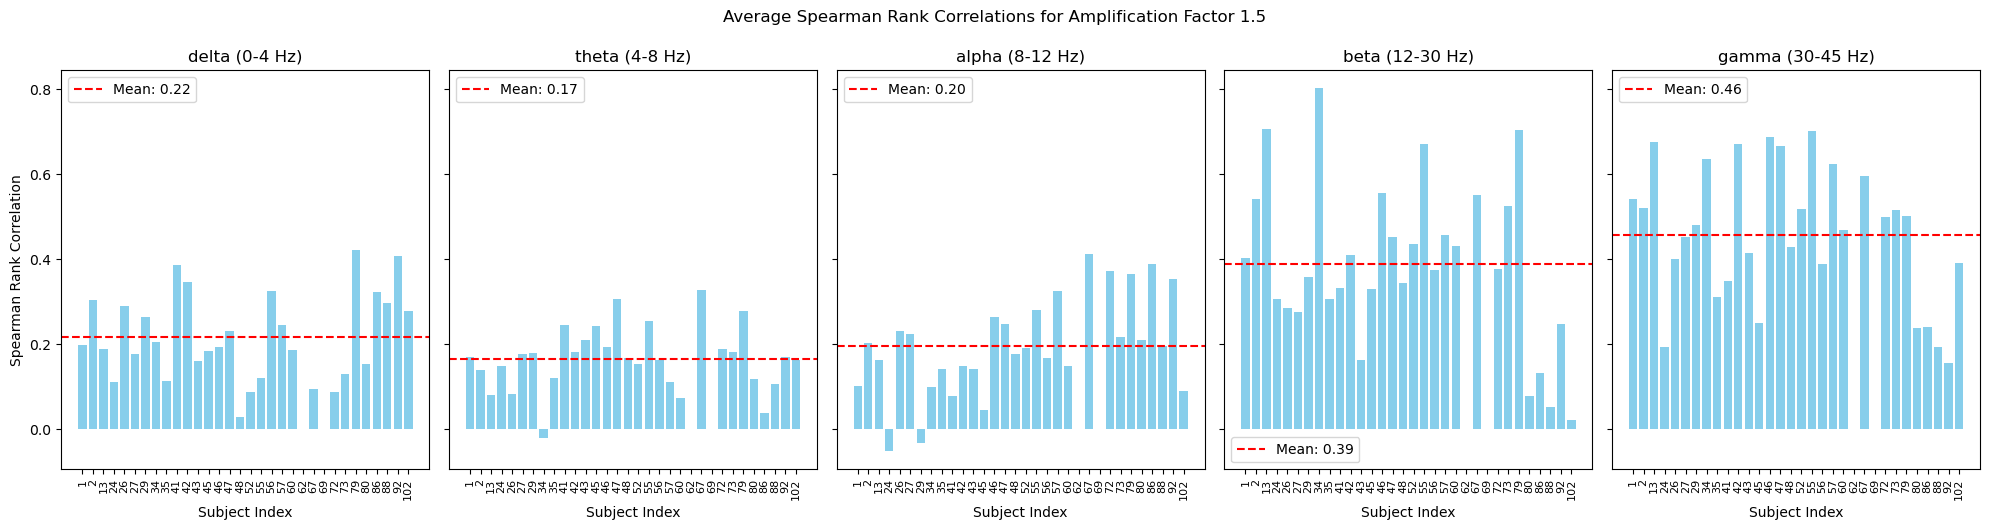

In [37]:
average_rank_correlations = average_rank_correlations_subject(spearman_correlations, freq_bands, amplification_factors)
all_corr_values = plot_average_correlations_subject(average_rank_correlations, freq_bands, amplification_factor=1.5)

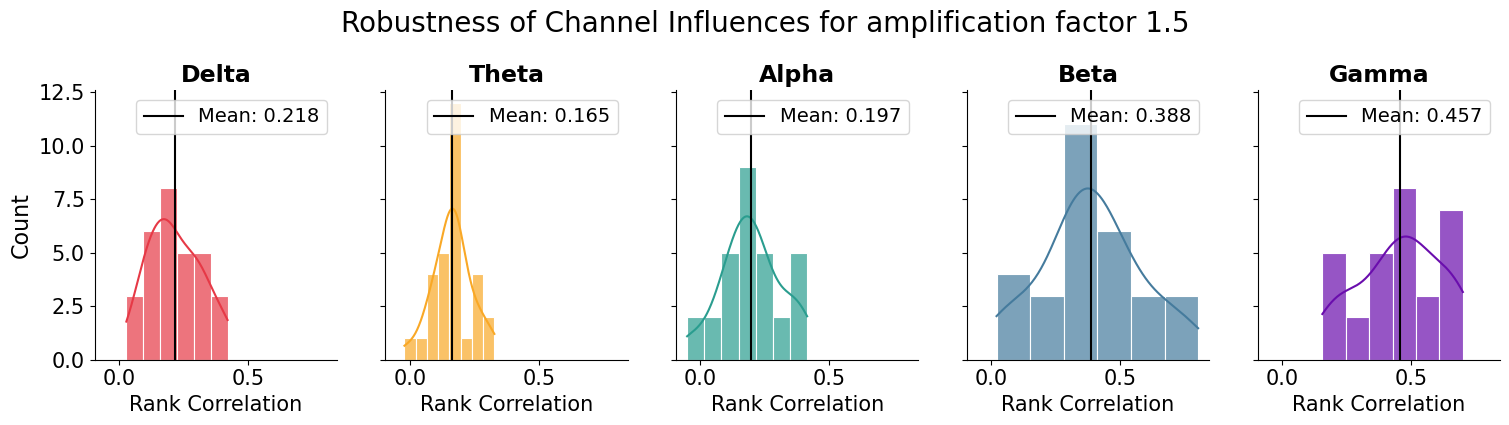

In [43]:
fig, _ = plot_average_correlations(all_corr_values, freq_bands, amplification_factor=1.5, use_abs=False)
plt.savefig("power_robustness_spearman_rank_correlations.png", bbox_inches='tight', dpi=300)

#plot_average_correlations(all_corr_values, freq_bands, amplification_factor=1.5, nan_treatment='zero')

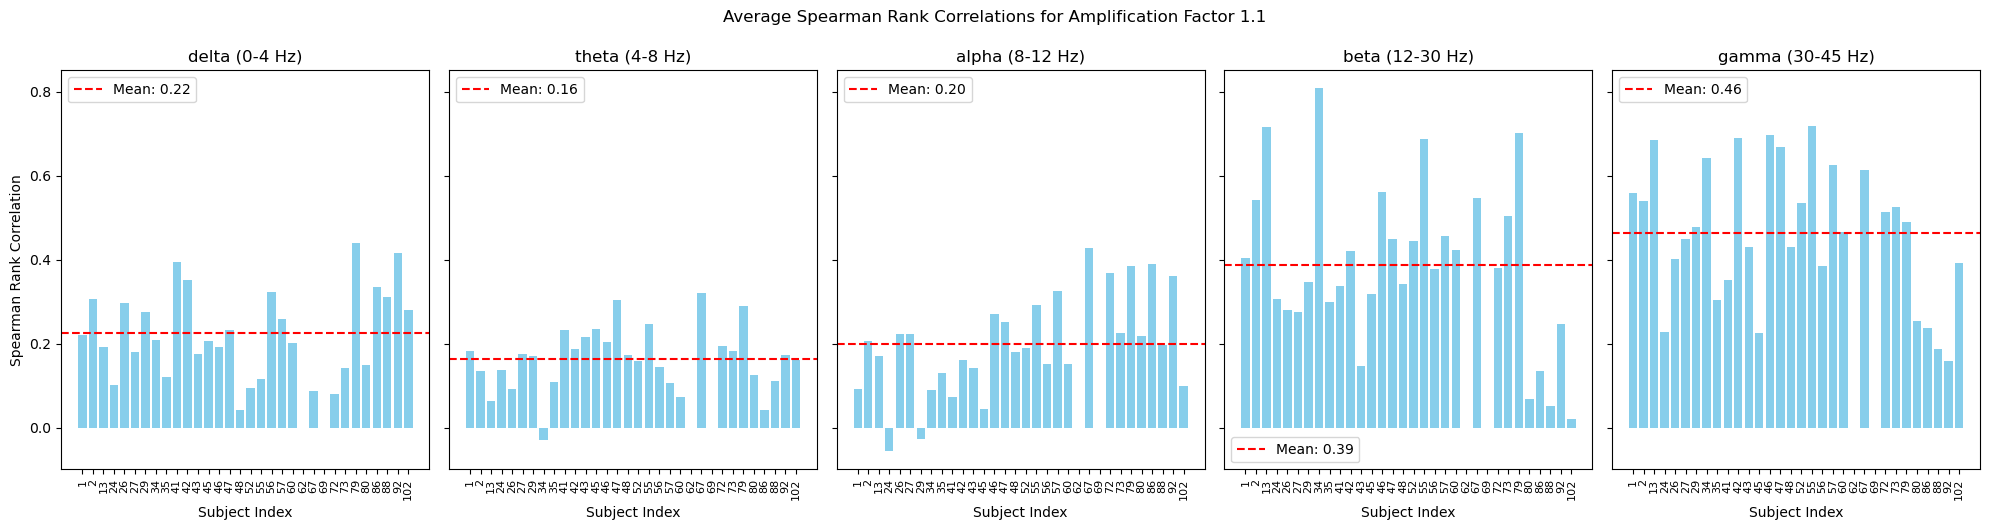

In [18]:
average_rank_correlations = average_rank_correlations_subject(spearman_correlations, freq_bands, amplification_factors)
all_corr_values = plot_average_correlations_subject(average_rank_correlations, freq_bands, amplification_factor=1.1)

In [20]:
#fig, _ = plot_average_correlations(all_corr_values, freq_bands, amplification_factor=1.1)

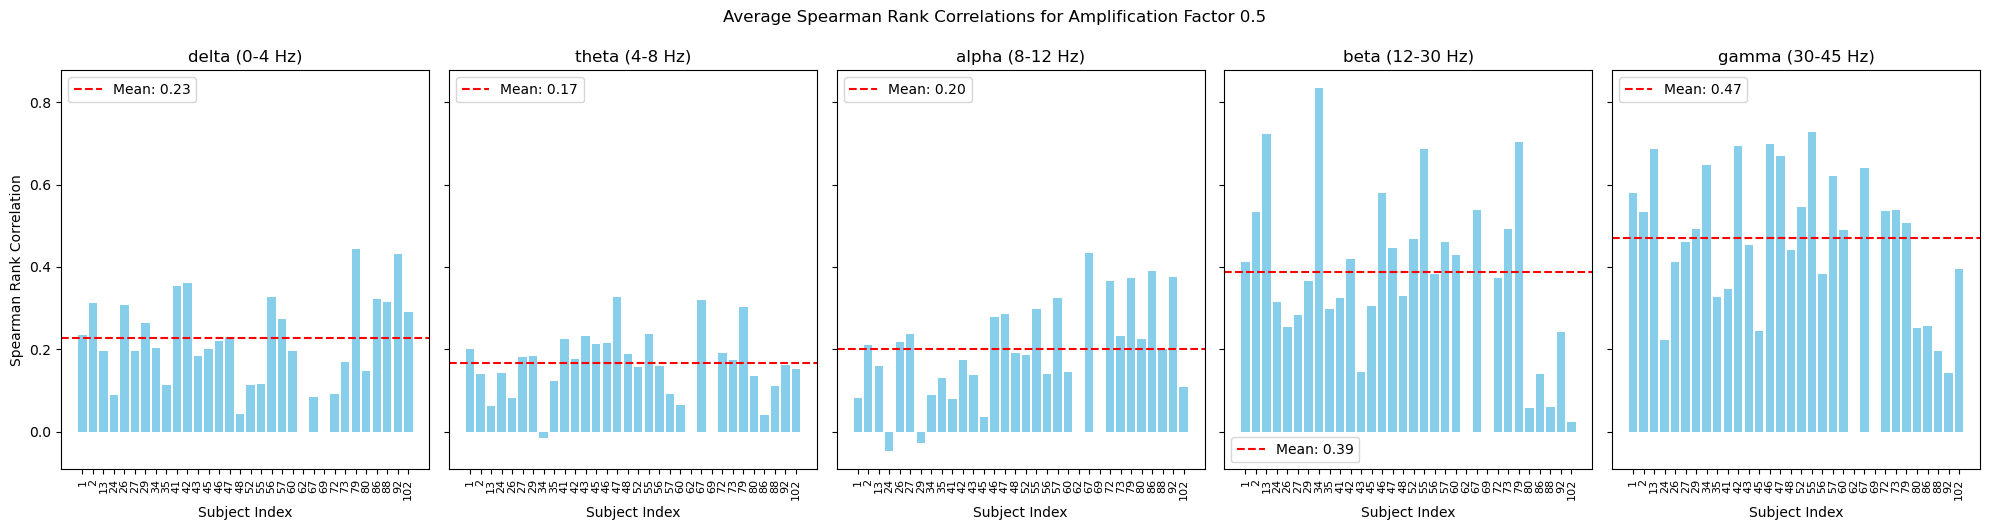

In [19]:
average_rank_correlations = average_rank_correlations_subject(spearman_correlations, freq_bands, amplification_factors)
all_corr_values = plot_average_correlations_subject(average_rank_correlations, freq_bands, amplification_factor=0.5)

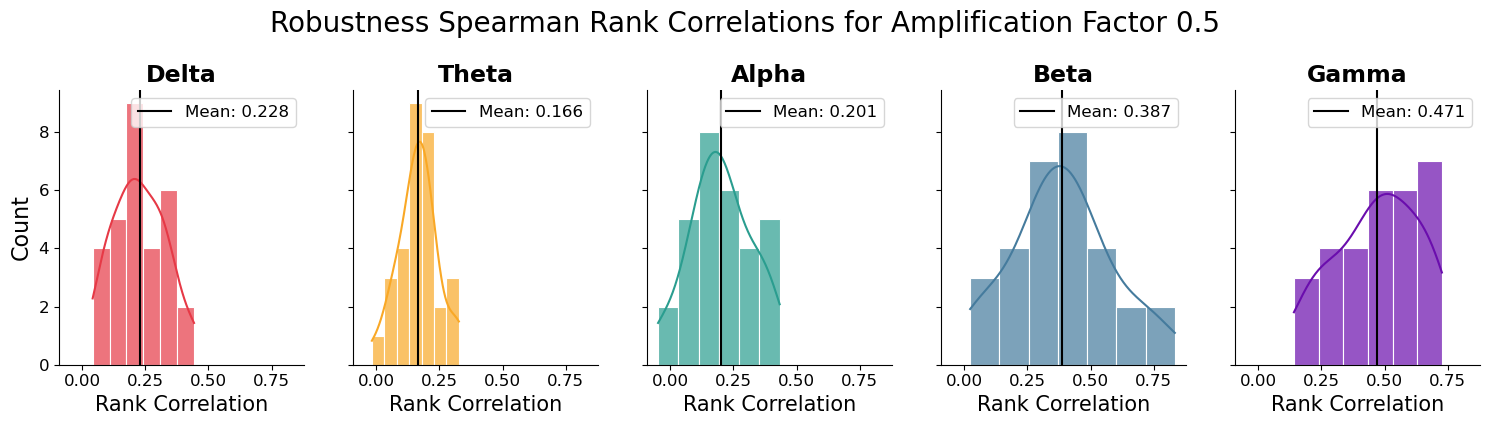

In [20]:
fig, _ = plot_average_correlations(all_corr_values, freq_bands, amplification_factor=0.5)

## top k channels

In [9]:
def get_top_channels(median_diff_per_channel, freq_bands, amplification_factors, top_k=10):
 
    top_channels_median = {}
  
    prediction_diff_median = {}
    
    for band_name in freq_bands.keys():
     
        top_channels_median[band_name] = {}
       
        prediction_diff_median[band_name] = {}
        
        for factor in amplification_factors:
            median_diffs = median_diff_per_channel[band_name][factor]
            # Sort the channels based on their differences
            sorted_median_diffs = sorted(median_diffs.items(), key=lambda item: item[1], reverse=True)
            
            # Select the top k channels
            top_channels_median[band_name][factor] = [ch for ch, _ in sorted_median_diffs[:top_k]]
            
            # Store the prediction differences for the top k channels
            prediction_diff_median[band_name][factor] = {ch: median_diffs[ch] for ch in top_channels_median[band_name][factor]}
    
    return top_channels_median, prediction_diff_median

In [106]:
len(median_diff_all_reps)

2

In [10]:
def get_top_channels_all_subjects(median_diff_all_reps, freq_bands, amplification_factors, top_k=5):
    top_channels_all_subjects = []
    #prediction_diff_all_subjects = {}
    
    for rep in range(len(median_diff_all_reps)):
        #top_channels_all_subjects[rep] = {}
        #prediction_diff_all_subjects[rep] = {}
        top_channels_all_subjects.append({})
        for subject in median_diff_all_reps[rep].keys():
            
            #top_channels_all_subjects[rep][subject] = {}
            #prediction_diff_all_subjects[rep][subject] = {}

            median_diff_per_channel = median_diff_all_reps[rep][subject]
            top_channels_median, _= get_top_channels(median_diff_per_channel, freq_bands, amplification_factors, top_k=top_k)

            top_channels_all_subjects[rep][subject] = top_channels_median
            
            #top_channels_all_subjects[rep][subject] = top_channels_median
            #prediction_diff_all_subjects[rep][subject] = prediction_diff_median

    return top_channels_all_subjects

In [117]:
top_channels_all_reps = get_top_channels_all_subjects(median_diff_all_reps, freq_bands, amplification_factors, top_k=5)


In [121]:
top_channels_all_reps [0]

{1: {'delta': {0.5: ['C1', 'Oz', 'PO8', 'F6', 'CP4'],
   0.8: ['C1', 'Oz', 'PO8', 'F6', 'CP4'],
   0.9: ['C1', 'Oz', 'PO8', 'F6', 'FT8'],
   1.1: ['C1', 'Oz', 'PO8', 'F6', 'CP4'],
   1.2: ['C1', 'Oz', 'PO8', 'F6', 'CP4'],
   1.5: ['C1', 'Oz', 'F6', 'PO8', 'FT8']},
  'theta': {0.5: ['Oz', 'C1', 'F5', 'O2', 'CP4'],
   0.8: ['Oz', 'C1', 'F5', 'O2', 'CP4'],
   0.9: ['Oz', 'C1', 'F5', 'O2', 'CP4'],
   1.1: ['Oz', 'C1', 'F5', 'O2', 'CP4'],
   1.2: ['Oz', 'C1', 'F5', 'O2', 'CP4'],
   1.5: ['Oz', 'C1', 'F5', 'CP4', 'O2']},
  'alpha': {0.5: ['CP4', 'CP6', 'C1', 'F5', 'F6'],
   0.8: ['CP4', 'CP6', 'C1', 'F5', 'F6'],
   0.9: ['CP4', 'CP6', 'C1', 'F5', 'F6'],
   1.1: ['CP4', 'CP6', 'C1', 'F5', 'F6'],
   1.2: ['CP4', 'CP6', 'C1', 'F5', 'F6'],
   1.5: ['CP4', 'CP6', 'F6', 'C1', 'F5']},
  'beta': {0.5: ['CP6', 'O1', 'CP4', 'O2', 'CP5'],
   0.8: ['CP6', 'O1', 'CP4', 'O2', 'CP5'],
   0.9: ['CP6', 'O1', 'CP4', 'CP5', 'PO7'],
   1.1: ['CP6', 'O1', 'CP4', 'PO7', 'CP5'],
   1.2: ['CP6', 'O1', 'CP4', 'PO7',

In [123]:
def compute_topk_agreement_pert(top_channels_all_reps, k=5):
    top_channel_agreement = {}
    # Get all subjects that exist in both repetitions
    list_pairs = itertools.combinations(np.arange(0,len(top_channels_all_reps)), 2)
    subjects = top_channels_all_reps[0].keys()
    
    for l1,l2 in list_pairs:
        top_channel_agreement[(l1,l2)] = {}
        for subject in subjects:
            top_channel_agreement[(l1,l2)][subject] = {}
            for band in freq_bands.keys():
                for factor in amplification_factors:
                    top_channels1 = top_channels_all_reps[l1][subject][band][factor]
                    top_channels2 = top_channels_all_reps[l2][subject][band][factor]
                    agreement = len(set(top_channels1).intersection(set(top_channels2)))/k
                    top_channel_agreement[(l1,l2)][subject][band] = agreement
    return top_channel_agreement

In [126]:
res =compute_topk_agreement_pert(top_channels_all_reps, k=5)

# robustness of explanation function

# correlation

In [48]:
topk_abs_all_reps = []
topk_all_reps = []
for rep in [3,4]:
    topk_abs = load_all_subjects_topk(rep=rep, take_abs=True)
    topk = load_all_subjects_topk(rep=rep, take_abs=False)
    topk_abs_all_reps.append(topk_abs)
    topk_all_reps.append(topk)

In [61]:
topk_abs_all_reps[0]

{1: {'Fp1': 0.8937683381386379,
  'Fp2': 0.5474499042229332,
  'F3': 0.3620447539800842,
  'F4': 0.5223723176462818,
  'C3': 0.6824260521788093,
  'C4': 0.6209178452340873,
  'P3': 0.7560807185159895,
  'P4': 0.6193969958198668,
  'O1': 3.1117206722902377,
  'O2': 2.059814628257041,
  'F7': 0.40331323618457454,
  'F8': 0.596253736409795,
  'T7': 0.6611029179517528,
  'T8': 0.4373445055445196,
  'P7': 1.0429514941337994,
  'P8': 0.7132629680630714,
  'Fz': 0.33582885428994996,
  'Cz': 1.151649910239633,
  'Pz': 0.34131723216314674,
  'Iz': 2.0901597615415524,
  'FC1': 0.7795298024231107,
  'FC2': 1.3864121437126635,
  'CP1': 0.8621688188716387,
  'CP2': 0.5216454164975333,
  'FC5': 0.3795960841826958,
  'FC6': 0.5364827892006784,
  'CP5': 1.7844168159717004,
  'CP6': 1.3800205031714665,
  'F1': 1.1969624495751026,
  'F2': 0.34184981031772443,
  'C1': 0.7304308019659576,
  'C2': 0.475113411916023,
  'P1': 1.4396119150987565,
  'P2': 2.9701860861373177,
  'AF3': 0.407915805500545,
  'AF4'

In [46]:
def compute_correlations_topk(topk_all_reps):
    # Initialize dictionaries to store correlations
    pearson_corrs = {}
    spearman_corrs = {}
    # Get all subjects that exist in both repetitions
    list_pairs = itertools.combinations(np.arange(0,len(topk_all_reps)), 2)
    subjects = topk_all_reps[0].keys()
    for l1,l2 in list_pairs:
        pearson_corrs[(l1,l2)] = {}
        spearman_corrs[(l1,l2)] = {}
   
        topk1 = topk_all_reps[l1]
        topk2 = topk_all_reps[l2]
        for subject in subjects:
            pearson_corrs[(l1,l2)][subject] = {}
            spearman_corrs[(l1,l2)][subject] = {}

            channels = topk1[subject].keys()
            # Extract values for correlation calculation
            values1 = [topk1[subject][ch] for ch in channels]
            values2 = [topk2[subject][ch] for ch in channels]

            # Calculate correlations
            pearson_corr, _ = stats.pearsonr(values1, values2)
            spearman_corr, _ = stats.spearmanr(values1, values2)
    return pearson_corr, spearman_corr


In [ ]:
compute_correlations_topk(topk_abs_all_reps)

In [ ]:
compute_correlations_topk(topk_all_reps)

## top channel agreement

In [51]:
def get_top_k_keys(d, k):
    """
    Returns the top k keys in a dictionary that have the highest values.

    Parameters:
    d (dict): The input dictionary.
    k (int): The number of top keys to return.

    Returns:
    list: A list of the top k keys with the highest values.
    """
    # Sort the dictionary by values in descending order and get the top k keys
    top_k_keys = sorted(d, key=d.get, reverse=True)[:k]
    return top_k_keys



['e', 'b', 'c']


In [ ]:
def compute_topk_agreement(topk_all_reps, k=5):
    top_k_agreement = {}
    # Get all subjects that exist in both repetitions
    list_pairs = itertools.combinations(np.arange(0,len(topk_all_reps)), 2)
    subjects = topk_all_reps[0].keys()
    for l1,l2 in list_pairs:
        top_k_agreement[(l1,l2)] = {}
        topk1 = topk_all_reps[l1]
        topk2 = topk_all_reps[l2]
        for subject in subjects:
            top_k_agreement[(l1,l2)][subject] = {}
            #channels = topk1[subject].keys()
            # Extract values for correlation calculation
            top_k_subject = get_top_k_keys(topk1[subject], k)
            topk_k_subject2 = get_top_k_keys(topk2[subject], k)
           
            top_k_agreement[(l1,l2)][subject] = len(set(top_k_subject).intersection(set(topk_k_subject2)))/k
    return top_k_agreement

(0.29608593913002235, 0.34409558210614066)

(-0.0027530097897151256, -0.05062517365934983)

In [68]:
compute_topk_agreement(topk_abs_all_reps)

{(0, 1): {1: 0.8,
  2: 0.8,
  13: 0.4,
  24: 0.2,
  26: 0.6,
  27: 0.4,
  29: 0.6,
  34: 0.8,
  35: 0.4,
  41: 0.6,
  42: 0.6,
  43: 0.6,
  45: 0.6,
  46: 0.8,
  47: 0.6,
  48: 0.6,
  52: 0.4,
  55: 0.8,
  56: 0.8,
  57: 0.6,
  60: 0.8,
  62: 0.8,
  67: 0.4,
  69: 0.2,
  72: 0.6,
  73: 0.8,
  79: 0.8,
  80: 0.0,
  86: 0.4,
  88: 0.4,
  92: 0.4,
  102: 0.0}}

In [69]:
compute_topk_agreement(topk_all_reps)

{(0, 1): {1: 0.4,
  2: 0.0,
  13: 0.2,
  24: 0.0,
  26: 0.2,
  27: 0.0,
  29: 0.0,
  34: 0.0,
  35: 0.2,
  41: 0.4,
  42: 0.2,
  43: 0.2,
  45: 0.2,
  46: 0.2,
  47: 0.2,
  48: 0.0,
  52: 0.0,
  55: 0.2,
  56: 0.0,
  57: 0.0,
  60: 0.2,
  62: 0.4,
  67: 0.0,
  69: 0.0,
  72: 0.2,
  73: 0.2,
  79: 0.2,
  80: 0.0,
  86: 0.2,
  88: 0.2,
  92: 0.2,
  102: 0.0}}